## ReAct Agent Architecture

Aim -> This is the intuition behind ReAct, a general agent architecture.

1. Act ----> Let the model call specific tool
2. Observe ----> Pass the tool output back to the model
3. Reason ----> Let the model reason about the tool output to decide what to do next (e.g- call another tool or respond directly)

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "ReAct Agent"

In [3]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

api_wrappper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper= api_wrappper_arxiv)

wiki_wrapper = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper= wiki_wrapper)

print(arxiv.name)
print(wiki.name)

arxiv
wikipedia


In [4]:
print(arxiv.invoke('What is Mathematical Physics?'))

Published: 2014-04-04
Title: Developing a 21st Century Global Library for Mathematics Research
Authors: Committee on Planning a Global Library of the Mathematical Sciences
Summary: Developing a 21st Century Global Library for Mathematics Research discusses how information about what the mathematical literature contains can be formalized and made easier to express, encode, and explore. Many of the tools necessary to make this information system a reality will require much more than indexing and w


In [5]:
print(wiki.invoke('Black Hole'))

Page: Black hole
Summary: A black hole is an astronomical body so compact that its gravity prevents anything, including light, from escaping. Albert Einstein's theory of general relativity, which describes gravitation as the curvature of spacetime, predicts that any sufficiently compact mass will form a black hole. The boundary of no escape is called the event horizon. In general relativity, crossing a black hole's event horizon traps an object inside but produces no locally detectable change. G


In [6]:
## Custom Functions
def multiply(a:int, b:int) -> int:
    """Multiply a and b
    
    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a:int, b:int) -> int:
    """Adds a and b
    
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a:int, b:int) -> float:
    """Divide a and b
    
    Args:
        a: first int
        b: second int
    """
    return a / b

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()
tavily.invoke("Yesterday's IPL results")

C:\Users\singh\AppData\Local\Temp\ipykernel_27228\1274312556.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'Who won yesterday IPL match | Yesterday IPL Match Result: Match Highlights, Stats & More',
  'url': 'https://www.crictracker.com/yesterday-ipl-match-result/',
  'content': "Facebook\n\nlogo\nCricket Icons\nuser name\nlogo\n\n# Who won yesterday IPL match\n\n## Who won yesterday’s IPL 2026 match?\n\nMumbai Indians beat Lucknow Super Giants by 6wickets in Match 47 of IPL 2026.\n\n### Yesterday's IPL Match Result\n\n|  |  |  |\n --- \n| Yesterday's IPL Match | Winner | Result |\n| MI vs LSG | MI | Won by 6 wickets |\n\n### Yesterday's IPL Match Scoreboard\n\n#### IPL 2026 Match 47: (MI vs LSG)\n\n|  |  |\n --- |\n| Team | Score |\n| LSG | 228/5 (20) |\n| MI | 229/4 (18.4) |\n\n#### Yesterday's IPL Match Top Performers\n\n#### IPL 2026 Match 47: (MI vs LSG) [...] #### IPL 2026 Match 47: (MI vs LSG)\n\n|  |  |  |  |\n ---  --- |\n| Category | Player | Team | Performance |\n| Most Runs | Rohit Sharma | MI | 84 (44) |\n| Most Wickets | Corbin Bosch | MI | 2/20 (2) |\n| Most Sixes 

In [9]:
tools = [arxiv, wiki, add, multiply, divide, tavily]

from langchain_groq import ChatGroq
llm = ChatGroq(model= os.getenv('GROQ_MODEL'), api_key= os.getenv('GROQ_API_KEY'))
LLM = llm.bind_tools(tools=tools)

In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

LLM.invoke([HumanMessage(content= f"What is the recent AI news?")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the recent AI news?" They likely want a summary of recent AI news. Need up-to-date info. Use search tool. Use tavily_search_results_json to get recent AI news. Then summarize.', 'tool_calls': [{'id': 'fc_d0302c2b-269c-45e0-9377-0bd8cb93600d', 'function': {'arguments': '{"query":"latest AI news 2024 May"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 379, 'total_tokens': 463, 'completion_time': 0.174047213, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.01474038, 'prompt_tokens_details': None, 'queue_time': 0.050836389, 'total_time': 0.188787593}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019df5f1-3471-78a2-8fa3-bc0ffa4c64e8-0', tool_calls

In [12]:
LLM.invoke([HumanMessage(content= f"What is the recent AI news?")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news 2024'},
  'id': 'fc_f305d99a-4660-4e80-8e21-809f34a5b2b0',
  'type': 'tool_call'}]

In [14]:
## State Schema
from dataclasses import dataclass
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

@dataclass
class State:
    messages: Annotated[list[AnyMessage], add_messages]

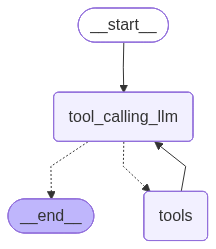

In [18]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage

## Node Defination

def tool_calling_llm(state: State):
    system = SystemMessage(content=(
        "You MUST use the provided add, multiply, and divide tools "
        "for ALL arithmetic operations, no matter how simple. "
        "Never compute math yourself."
    ))
    return {"messages": [LLM.invoke([system] + state.messages)]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
content = (
    "Provide me top 10 recent AI news. "
    "Also, use the add tool to compute 5 + 5, "
    "then use the multiply tool to multiply that result by 3."
)

messages = graph.invoke({"messages": HumanMessage(content= content)})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me top 10 recent AI news. Also, use the add tool to compute 5 + 5, then use the multiply tool to multiply that result by 3.
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_3b79a1c7-303f-413b-aae0-f94bc446847a)
 Call ID: fc_3b79a1c7-303f-413b-aae0-f94bc446847a
  Args:
    query: latest AI news 2024
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "The 10 Biggest AI News Stories Of 2024: Nvidia, GenAI And Security", "url": "https://www.crn.com/news/ai/2024/the-10-biggest-ai-news-stories-of-2024-nvidia-genai-and-cybersecurity", "content": "Gartner predicts that at least 15 percent of day-to-day work decisions will be made autonomously through agentic AI by 2028. “Organizations have long wanted to promote high-performing teams, improve cross-functio

## Agent Memory

In [20]:
content = "Multiply 3 and 9"
messages = graph.invoke({"messages": HumanMessage(content=content)})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 3 and 9
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_3b88f0f9-51ce-4e23-924f-6b58d0b22d13)
 Call ID: fc_3b88f0f9-51ce-4e23-924f-6b58d0b22d13
  Args:
    a: 3
    b: 9
================================= Tool Message =================================
Name: multiply

27
================================== Ai Message ==================================

27


In [ ]:
content = "Divide it by 5"
messages = graph.invoke({"messages": HumanMessage(content=content)})
for m in messages["messages"]:
    m.pretty_print()

## As we can see the memory is not created

================================ Human Message =================================

Divide it by 5
================================== Ai Message ==================================

I’m not sure which number you’d like to divide by 5. Could you let me know the value you want to divide?


### MemorySaver

LangGraph can use a checkpoint to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing Langgraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory Key-value store for graph state.

All we need to do is simply complie the graph with a checkpointer, and our graph has memory!

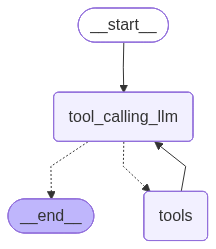

In [22]:
## Specify the Thread
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import MemorySaver

## Node Defination

def tool_calling_llm(state: State):
    system = SystemMessage(content=(
        "You MUST use the provided add, multiply, and divide tools "
        "for ALL arithmetic operations, no matter how simple. "
        "Never compute math yourself."
    ))
    return {"messages": [LLM.invoke([system] + state.messages)]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge("tools", "tool_calling_llm")

memory = MemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [28]:
## Specify the Thread
config = {"configurable" : {"thread_id" : "1"}}
content = "Add 12 + 13"

messages = graph_memory.invoke({"messages": HumanMessage(content=content)}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5)
 Call ID: fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad)
 Call ID: fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ========================

In [30]:
content = "Divide it by 5"
messages = graph_memory.invoke({"messages": HumanMessage(content=content)}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5)
 Call ID: fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad)
 Call ID: fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ========================

In [31]:
content = "Multiply it by 25"
messages = graph_memory.invoke({"messages": HumanMessage(content=content)}, config=config)
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5)
 Call ID: fc_e07a5d9a-8b30-4e11-8b59-6dd2ab0715f5
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is **25**.
================================ Human Message =================================

Add 12 + 13
================================== Ai Message ==================================
Tool Calls:
  add (fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad)
 Call ID: fc_4a5ae87f-f332-4f62-b1bd-4b366a40e6ad
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ========================